# Reproduce Negative Distribution Before and After Augmentation

This notebook reproduces the two distribution plots from `2.Data Augmentation.ipynb` using existing data files only.

It does **not** modify or regenerate any data.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

table1_path = "datasets/Table 1.csv"
protein_lengths_path = "data/protein_lengths.csv"
idr_anchor_path = "data/collected_st_amino_acids_idrscore_anchorscore.csv"
phospho_path = "data/preds_swissprot_ST.csv"
after_augmentation_path = "data/labeled_and_augmented_negative_data.csv"

length_num_bins = 2
idr_num_bins = 2
anchor_num_bins = 4
phospho_num_bins = 2

def bin_feature(df, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins):
    df = df.copy()
    df["binned_protein_length"] = pd.cut(df["protein_length"], bins=length_num_bins, labels=False)
    df["binned_iupred_score"] = pd.cut(df["iupred_score"], bins=idr_num_bins, labels=False)
    df["binned_anchor_score"] = pd.cut(df["anchor_score"], bins=anchor_num_bins, labels=False)
    df["binned_phospho_score"] = pd.cut(df["phospho_score"], bins=phospho_num_bins, labels=False)
    df["stratification_label"] = (
        df["binned_protein_length"].astype(str)
        + "_"
        + df["binned_iupred_score"].astype(str)
        + "_"
        + df["binned_anchor_score"].astype(str)
        + "_"
        + df["binned_phospho_score"].astype(str)
    )
    return df

def plot_distribution(comparison_distribution, reference_distribution, comparison_label, title, color, reference_color="#94a3b8", reference_alpha=0.55):
    labels = list(reference_distribution.index)

    def format_label(label):
        length_bin, idr_bin, anchor_bin, phospho_bin = label.split("_")
        return "\n".join([length_bin, idr_bin, anchor_bin, phospho_bin])

    display_labels = [format_label(label) for label in labels]
    x = list(range(len(labels)))

    fig, ax = plt.subplots(figsize=(20, 8), facecolor="white")
    ax.set_facecolor("#f8fafc")
    ax.bar(
        x,
        comparison_distribution.reindex(labels, fill_value=0).values,
        label=comparison_label,
        color=color,
        edgecolor="#1e3a5f",
        linewidth=0.6,
    )
    ax.bar(
        x,
        reference_distribution.reindex(labels, fill_value=0).values,
        label="Whole proteome distribution",
        color=reference_color,
        alpha=reference_alpha,
        edgecolor="#1e3a5f",
        linewidth=0.4,
    )
    ax.set_xlabel("Stratification label", fontsize=14, labelpad=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", pad=14)
    ax.text(
        0,
        0.985,
        "Distribution across stratification bins",
        transform=ax.transAxes,
        fontsize=10,
        color="#475569",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(display_labels, fontsize=11, linespacing=1.1, fontfamily="monospace")
    ax.tick_params(axis="y", labelsize=12, colors="#334155")
    ax.tick_params(axis="x", pad=8, colors="#334155")
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#94a3b8")
    ax.spines["bottom"].set_color("#94a3b8")
    ax.legend(frameon=False, fontsize=12)
    fig.text(
        0.100,
        0.145,
        "length\nIDR\nanchor\nphospho",
        ha="left",
        va="bottom",
        fontsize=11,
        fontfamily="monospace",
    )
    plt.tight_layout(rect=(0.06, 0.08, 1, 1))
    plt.show()

## 1. Build the whole-proteome reference distribution

In [68]:
protein_lengths_df = pd.read_csv(protein_lengths_path)
protein_length_dict = protein_lengths_df.set_index("UniProt ID")["Protein Length"].to_dict()

protein_idr_df = pd.read_csv(idr_anchor_path)
protein_idr_df.columns = ["uniqueid", "position", "amino_acid", "iupred_score", "anchor_score"]
protein_idr_df["uniprot_id"] = protein_idr_df["uniqueid"].str.split("_", expand=True)[0]
protein_idr_df["prot_id_position"] = protein_idr_df["uniprot_id"] + "_" + protein_idr_df["position"].astype(str)

phospho_df = pd.read_csv(phospho_path)
phospho_df["prot_id_position"] = phospho_df["prot_id"] + "_" + phospho_df["position"].astype(str)
phospho_df.columns = ["prot_id", "position_x", "phospho_score", "prot_id_position"]

whole_df = pd.merge(protein_idr_df, phospho_df, on="prot_id_position", how="inner")
whole_df["protein_length"] = whole_df["prot_id"].map(protein_length_dict)
whole_df = whole_df[["uniqueid", "uniprot_id", "position", "prot_id_position", "protein_length", "iupred_score", "anchor_score", "phospho_score"]]
whole_df = whole_df.dropna()
whole_df = whole_df[(whole_df["protein_length"] < 4800) & (whole_df["protein_length"] > 100)]

whole_df = bin_feature(whole_df, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins)
whole_distribution = whole_df["stratification_label"].value_counts(normalize=True)
categories = list(whole_distribution.index)

print(f"Whole proteome rows used: {len(whole_df)}")
print(f"Number of stratification categories: {len(categories)}")

Whole proteome rows used: 1172480
Number of stratification categories: 32


## 2. Before augmentation: original labeled negative set

Original labeled negative rows matched to whole_df: 473


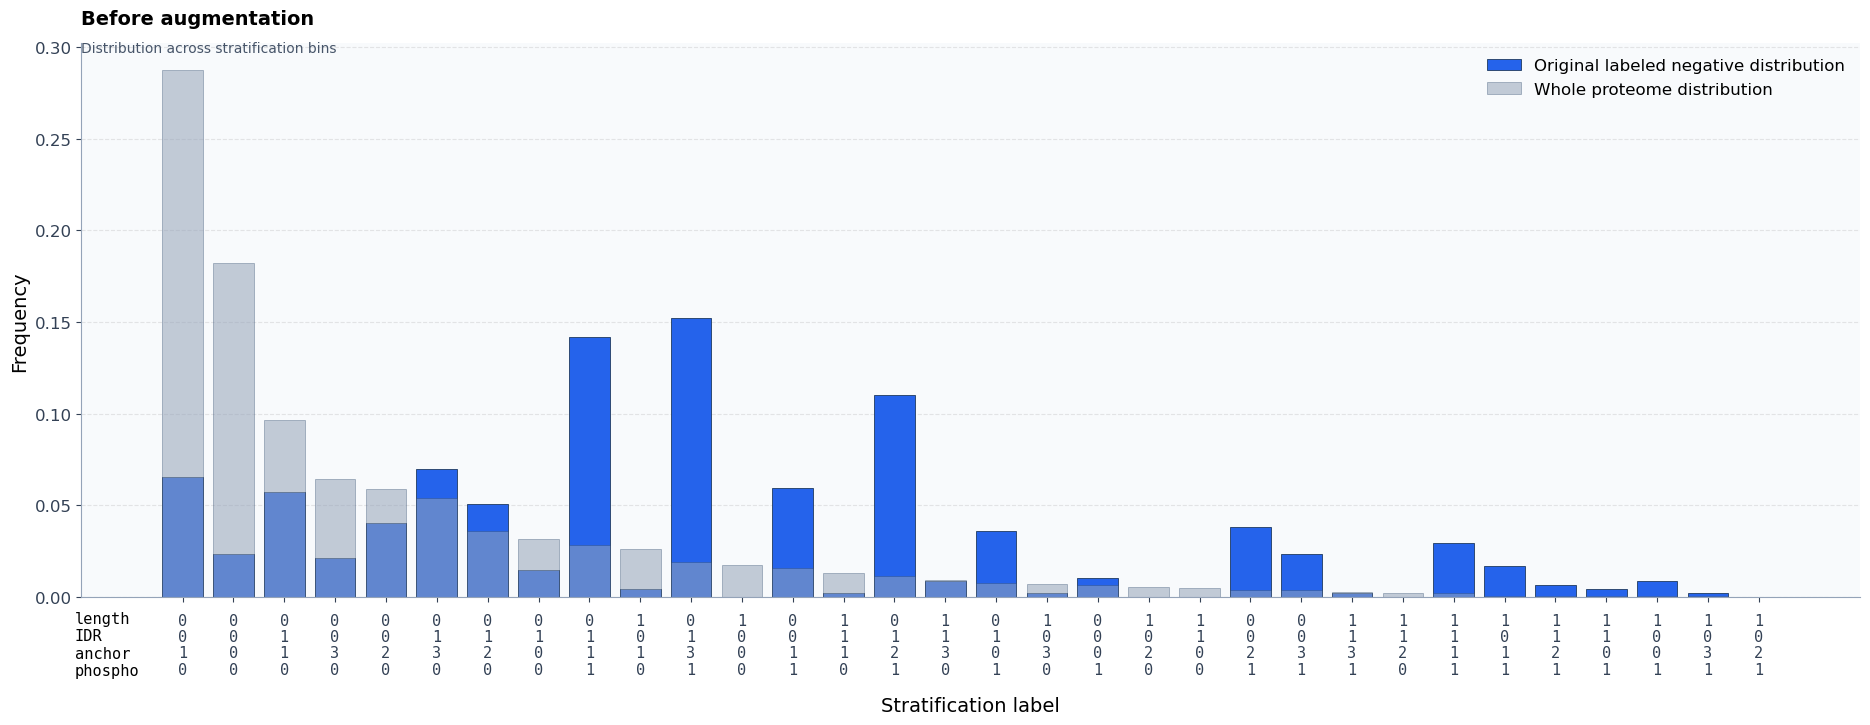

In [69]:
table1_df = pd.read_csv(table1_path)
table1_negative_df = table1_df[table1_df["label"] == 0].copy()
table1_negative_df["prot_id_position"] = (
    table1_negative_df["human homology accession"]
    + "_"
    + table1_negative_df["human homology site without letter"].astype(str)
)

before_df = whole_df[whole_df["prot_id_position"].isin(set(table1_negative_df["prot_id_position"]))].copy()
before_df = bin_feature(before_df, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins)
before_distribution = before_df["stratification_label"].value_counts(normalize=True).reindex(categories, fill_value=0)

print(f"Original labeled negative rows matched to whole_df: {len(before_df)}")
plot_distribution(
    before_distribution,
    whole_distribution.reindex(categories, fill_value=0),
    "Original labeled negative distribution",
    "Before augmentation",
    "#2563eb",
)

## 3. After augmentation: use the existing saved augmented negative dataset

Saved augmented negative rows: 2672


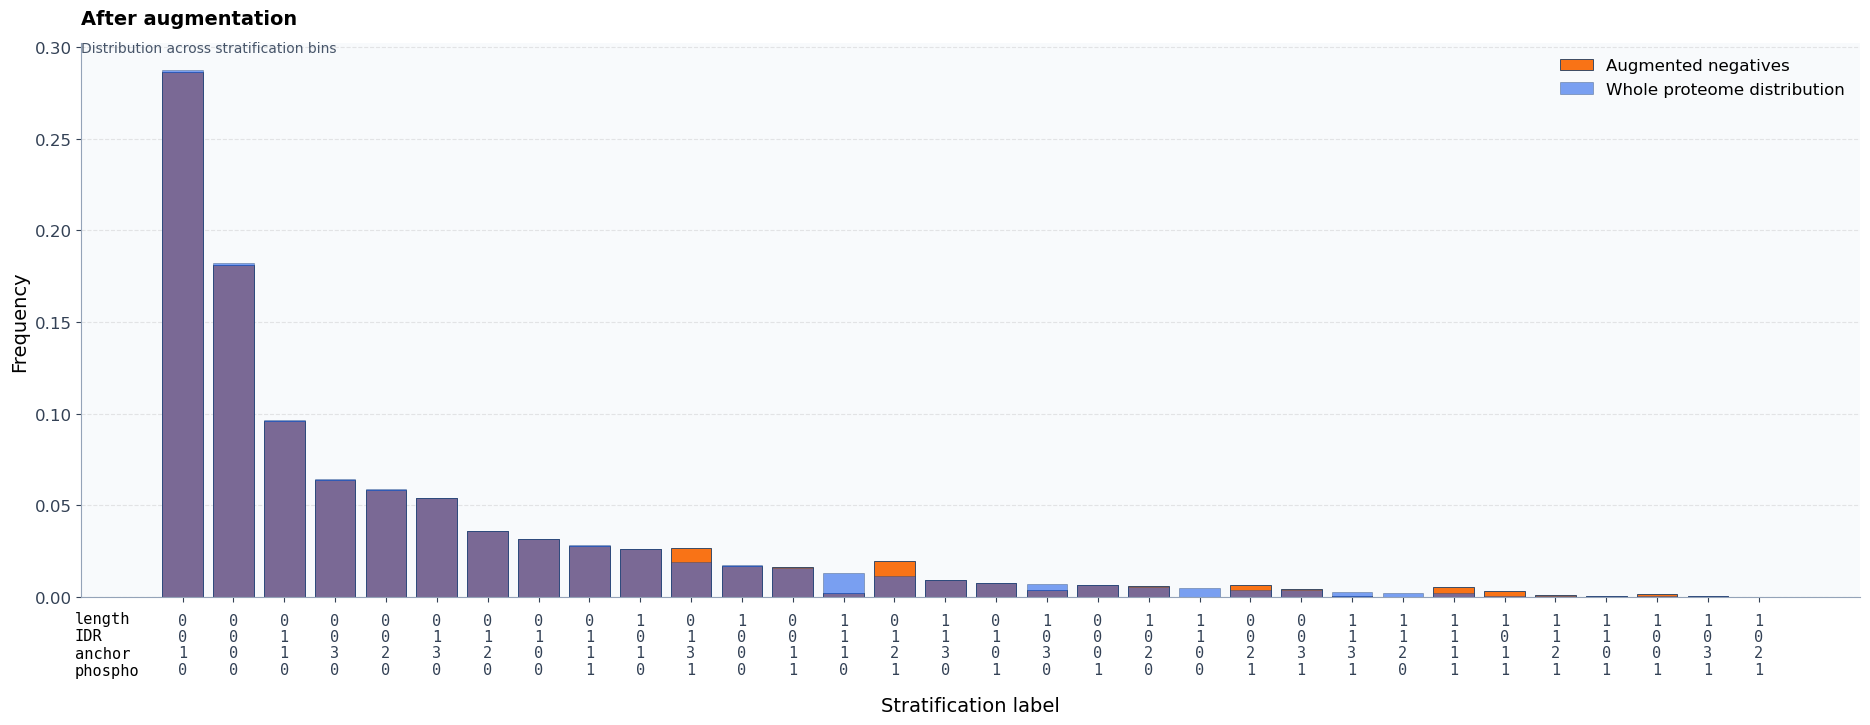

In [70]:
after_df = pd.read_csv(after_augmentation_path)

if "stratification_label" not in after_df.columns:
    after_df = bin_feature(after_df, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins)

after_distribution = after_df["stratification_label"].value_counts(normalize=True).reindex(categories, fill_value=0)

print(f"Saved augmented negative rows: {len(after_df)}")
plot_distribution(
    after_distribution,
    whole_distribution.reindex(categories, fill_value=0),
    "Augmented negatives",
    "After augmentation",
    "#f97316",
    reference_color="#2563eb",
    reference_alpha=0.6,
)